**PREVISÃO DA EFETIVAÇÃO DE MATRÍCULA DE CANDIDATOS CONVOCADOS NO SISU 2023/2**

Este projeto tem como objetivo desenvolver um modelo de Machine Learning capaz de prever se um candidato convocado na Lista de Espera do SISU 2023/2 efetivará sua matrícula. O projeto contempla as etapas de análise exploratória dos dados (EDA), pré-processamento, engenharia de atributos, treinamento dos modelos e avaliação dos resultados.

**1. IMPORTAÇÃO DAS BIBLIOTECAS**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_theme(style='whitegrid')

**2. CONFIGURAÇÃO DO AMBIENTE.**

In [ ]:
from google.colab import drive

# Monta o Google Drive para acesso aos arquivos do projeto
drive.mount('/content/drive')

Mounted at /content/drive


**3. DEFINIÇÃO DO DIRETÓRIO DE TRABALHO.**

In [ ]:
# Caminho da pasta onde a base de dados está armazenada
PATH = '/content/drive/MyDrive/PP_CD'

**4. CARREGAMENTO DA BASE DE DADOS.**

Nesta etapa é realizada a importação do conjunto de dados referente à Lista de Espera do SISU 2023.

In [ ]:
sisu = pd.read_csv(f"{PATH}/lista_de_espera_sisu_2023_2.csv", sep='|', encoding='latin1', low_memory=False)
pd.set_option('display.max_columns', None)
sisu.head(2)

,ANO,EDICAO,ETAPA,DS_ETAPA,CODIGO_IES,NOME_IES,SIGLA_IES,UF_IES,CODIGO_CAMPUS,NOME_CAMPUS,UF_CAMPUS,MUNICIPIO_CAMPUS,CODIGO_CURSO,NOME_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,PESO_L,PESO_CH,PESO_CN,PESO_M,PESO_R,NOTA_MINIMA_L,NOTA_MINIMA_CH,NOTA_MINIMA_CN,NOTA_MINIMA_M,NOTA_MINIMA_R,MEDIA_MINIMA,CPF,INSCRICAO_ENEM,INSCRITO,SEXO,DT_NASCIMENTO,UF_CANDIDATO,MUNICIPIO_CANDIDATO,OPCAO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_L_COM_PESO,NOTA_CH_COM_PESO,NOTA_CN_COM_PESO,NOTA_M_COM_PESO,NOTA_R_COM_PESO,NOTA_CANDIDATO,NOTA_CORTE,CLASSIFICACAO,APROVADO,MATRICULA
0,2023,2,7,LISTA DE ESPERA,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,RJ,Rio de Janeiro,1441998,SISTEMAS DE INFORMAÇÃO,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,15,NaN,1,1,2,4,3,"453,8","444,7","453,3","438,4",300,"418,04",XXX.398407-XX,221XXXXXX236,ALBERTH TEIXEIRA DA ROCHA,M,2001,RJ,Rio de Janeiro,2,"620,3","630,2","553,2","731,6",660,"620,3","630,2","1106,4","2926,4",1980,"660,3","660,69",16,S,NÃO CONVOCADO
1,2023,2,7,LISTA DE ESPERA,593,CENTRO FEDERAL DE EDUCAÇÃO TECNOLÓGICA CELSO S...,CEFET/RJ,RJ,1663,CEFET-RJ - MARIA DA GRAÇA,RJ,Rio de Janeiro,1441998,SISTEMAS DE INFORMAÇÃO,Bacharelado,Noturno,Semestral,NaN,A,Ampla concorrência,15,NaN,1,1,2,4,3,"453,8","444,7","453,3","438,4",300,"418,04",XXX.787587-XX,221XXXXXX458,ALEXANDRE VIANA GONCALVES,M,1994,RJ,Rio de Janeiro,1,"631,3","604,8","621,1","673,1",580,"631,3","604,8","1242,2","2692,4",1740,"628,25","660,69",27,S,NÃO CONVOCADO


**ETAPA 1 - ANÁLISE EXPLORATÓRIA (EDA)**

**1.1 INSPEÇÃO INICIAL DO CONJUNTO DE DADOS.**

Nesta etapa é realizada uma análise preliminar da base de dados com o objetivo de compreender sua dimensão, estrutura e qualidade. São verificados o número de registros, a quantidade de atributos, os tipos de dados, a existência de valores ausentes e de registros duplicados. **Essas informações são fundamentais para orientar as etapas posteriores de pré-processamento e modelagem**

In [ ]:
# Shape do conjunto de dados
sisu.shape

print(f'Número de registros: {sisu.shape[0]:,}'.replace(',', '.'))
print(f'Número de atributos: {sisu.shape[1]}')

Número de registros: 148.773
Número de atributos: 56


**INTERPRETAÇÃO:** O conjunto de dados possui 148.773 registros e 56 atributos. Cada linha representa um candidato inscrito na Lista de Espera do SISU 2023/2, enquanto cada coluna corresponde a uma característica do candidato, do curso, da instituição ou do processo seletivo.

**1.2 INFORMAÇÕES GERAIS DO CONJUNTO DE DADOS.**

Nesta etapa, é realizada uma inspeção da estrutura do conjunto de dados para identificar os tipos de variáveis, a presença de valores ausentes e a distribuição dos tipos de dados.

In [ ]:
# Informações gerais do conjunto de dados
sisu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148773 entries, 0 to 148772
Data columns (total 56 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ANO                    148773 non-null  int64  
 1   EDICAO                 148773 non-null  int64  
 2   ETAPA                  148773 non-null  int64  
 3   DS_ETAPA               148773 non-null  object 
 4   CODIGO_IES             148773 non-null  int64  
 5   NOME_IES               148773 non-null  object 
 6   SIGLA_IES              148773 non-null  object 
 7   UF_IES                 148773 non-null  object 
 8   CODIGO_CAMPUS          148773 non-null  int64  
 9   NOME_CAMPUS            148773 non-null  object 
 10  UF_CAMPUS              148773 non-null  object 
 11  MUNICIPIO_CAMPUS       148773 non-null  object 
 12  CODIGO_CURSO           148773 non-null  int64  
 13  NOME_CURSO             148773 non-null  object 
 14  GRAU                   148773 non-nu

In [ ]:
# Quantidade de variáveis por tipo de dado
sisu.dtypes.value_counts()

,count
object,43
int64,12
float64,1


**INTERPRETAÇÃO:**

A inspeção inicial revelou que o conjunto de dados é composto por 56 atributos, sendo 43 armazenados como object, 12 como int64 e apenas 1 como float64. Essa distribuição indica que grande parte das variáveis é categórica ou foi importada como texto.

Observa-se que diversas variáveis relacionadas às notas do ENEM, notas ponderadas, notas mínimas exigidas pelos cursos e nota de corte foram importadas como object, embora representem valores numéricos. Isso ocorre, provavelmente, porque os valores utilizam vírgula como separador decimal, impedindo que o Pandas os reconheça automaticamente como números.

Também foram identificadas colunas com valores ausentes, destacando-se:

**TP_COTA**

**PERCENTUAL_BONUS**

**NOTA_CORTE**

Esses atributos serão analisados individualmente durante a etapa de pré-processamento para definir a estratégia de tratamento mais adequada.

Outro ponto observado é que a base ocupa aproximadamente 63,6 MB de memória, permitindo que todas as etapas de análise e modelagem sejam executadas integralmente na memória, sem necessidade de técnicas de processamento distribuído.

**1.3 IDENTIFICAÇÃO DE VALORES AUSENTES.**

Nesta etapa, é realizada a identificação de valores ausentes no conjunto de dados. Essa análise é importante para definir quais atributos necessitarão de tratamento durante o pré-processamento, evitando perda de informação.

In [ ]:
# Tabela com quantidade e percentual de valores ausentes
valores_nulos = pd.DataFrame({
    'Valores Ausentes': sisu.isnull().sum(),
    'Percentual (%)': (sisu.isnull().sum() / len(sisu) * 100).round(2)})

valores_nulos = valores_nulos[valores_nulos['Valores Ausentes'] > 0]
valores_nulos.sort_values('Valores Ausentes', ascending=False)

,Valores Ausentes,Percentual (%)
PERCENTUAL_BONUS,140964,94.75
TP_COTA,83750,56.29
NOTA_CORTE,4032,2.71


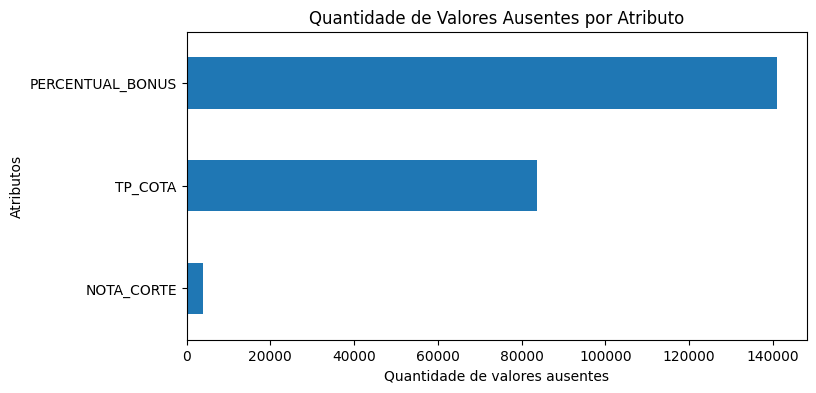

In [ ]:
# Gráfico com quantidade e percentual de valores ausentes.

import matplotlib.pyplot as plt

nulos = sisu.isnull().sum()
nulos = nulos[nulos > 0]

plt.figure(figsize=(8,4))
nulos.sort_values().plot(kind='barh')

plt.title('Quantidade de Valores Ausentes por Atributo')
plt.xlabel('Quantidade de valores ausentes')
plt.ylabel('Atributos')
plt.show()

**INTERPRETAÇÃO:**

A análise dos valores ausentes mostrou que apenas três atributos apresentam dados faltantes, indicando que o conjunto de dados possui boa qualidade em relação à completude das informações.

O atributo PERCENTUAL_BONUS apresentou o maior número de valores ausentes (140.964 registros, aproximadamente 94,75% da base). Esse comportamento é esperado, pois o bônus percentual é aplicado apenas em processos seletivos específicos, não sendo utilizado pela maioria das instituições.

A variável TP_COTA apresentou 83.750 valores ausentes (56,29%). Esses valores não representam necessariamente um erro de coleta, mas indicam candidatos inscritos na modalidade de Ampla Concorrência, conforme a documentação do SISU. Dessa forma, durante o pré-processamento, os valores ausentes poderão ser substituídos pela categoria "AMPLA_CONCORRENCIA", preservando a informação da modalidade de ingresso.

A variável NOTA_CORTE apresentou apenas 4.032 valores ausentes (2,71% da base). Como essa é uma variável numérica importante para o Problema B, será necessário definir uma estratégia de imputação adequada, como a substituição pela mediana ou outra abordagem justificada.

Os demais 53 atributos não apresentam valores ausentes, evidenciando que a base possui elevada qualidade e exigirá poucas intervenções relacionadas ao tratamento de dados faltantes.

**1.4 VERIFICAÇÃO DE REGISTROS DUPLICADOS.**

In [ ]:
# Quantidade de registros duplicados
sisu.duplicated().sum()

print(f'Registros duplicados: {sisu.duplicated().sum()}')

Registros duplicados: 0


**INTERPRETAÇÃO:**

A análise identificou que não existem registros duplicados no conjunto de dados, indicando que cada linha representa um candidato único na Lista de Espera do SISU 2023/2.

**2. DISTRIBUIÇÃO DA VARIÁVEL-ALVO (BALANCEAMENTO)**

Nesta etapa, analisa-se a distribuição da variável-alvo MATRICULA, verificando se as classes estão balanceadas ou desbalanceadas.

In [ ]:
# Frequência absoluta das classes
sisu['MATRICULA'].value_counts()

,count
MATRICULA,
NÃO CONVOCADO,69729
PENDENTE,34540
NÃO COMPARECEU,26085
EFETIVADA,16943
DOCUMENTACAO REJEITADA,1233
CANCELADA,243


In [ ]:
# Frequência relativa (%)
matricula_pct = (
    sisu['MATRICULA']
        .value_counts(normalize=True)
        .mul(100)
        .round(2))

print(matricula_pct)

MATRICULA
NÃO CONVOCADO             46.87
PENDENTE                  23.22
NÃO COMPARECEU            17.53
EFETIVADA                 11.39
DOCUMENTACAO REJEITADA     0.83
CANCELADA                  0.16
Name: proportion, dtype: float64


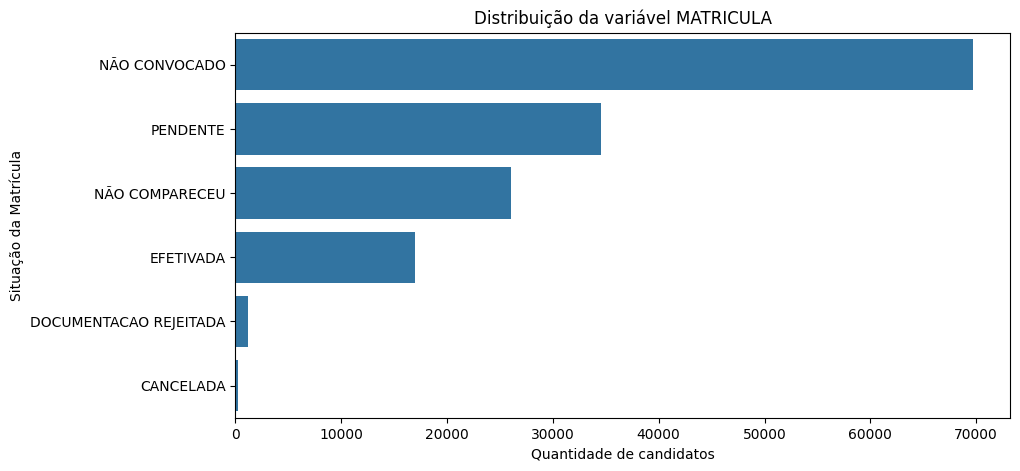

In [ ]:
# Visualização

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=sisu,
    y='MATRICULA',
    order=sisu['MATRICULA'].value_counts().index
)

plt.title('Distribuição da variável MATRICULA')
plt.xlabel('Quantidade de candidatos')
plt.ylabel('Situação da Matrícula')

plt.show()

**INTERPRETAÇÃO:**

A variável MATRICULA apresenta seis categorias distintas, representando os diferentes desfechos do processo de matrícula dos candidatos inscritos na Lista de Espera do SISU 2023/2.

Observa-se que a categoria **"NÃO CONVOCADO"** representa a maior parte dos registros da base, seguida pelas categorias **"PENDENTE"**, **"NÃO COMPARECEU"** e **"EFETIVADA"**. As categorias **"DOCUMENTAÇÃO REJEITADA"** e **"CANCELADA"** apresentam baixa frequência quando comparadas às demais.

Essa distribuição representa o estado original da base de dados e permite compreender o comportamento da variável antes da etapa de preparação dos dados.

Conforme definido no Problema B, o objetivo é prever se um candidato convocado efetivará sua matrícula. Dessa forma, durante a etapa de pré-processamento, os registros classificados como **"NÃO CONVOCADO"** serão removidos, pois não atendem à condição estabelecida pelo problema.

**3. VISUALIZAÇÕES EXPLORATÓRIAS**

**Gráfico 1 – Distribuição da Variável-Alvo**

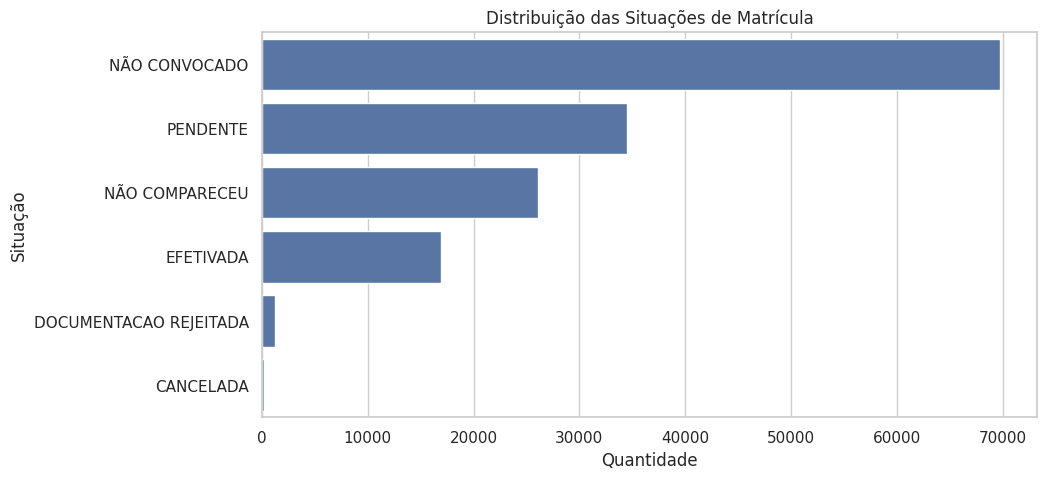

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=sisu,y='MATRICULA', order=sisu['MATRICULA'].value_counts().index)

plt.title('Distribuição das Situações de Matrícula')
plt.xlabel('Quantidade')
plt.ylabel('Situação')
plt.show()

A variável MATRICULA apresenta seis categorias distintas, representando as diferentes situações dos candidatos após a divulgação da Lista de Espera do SISU 2023/2. Observa-se que a categoria **"NÃO CONVOCADO"** concentra a maior quantidade de registros, seguida por **"PENDENTE"**, **"NÃO COMPARECEU"** e **"EFETIVADA"**. As categorias **"DOCUMENTAÇÃO REJEITADA"** e **"CANCELADA"** apresentam baixa frequência na base de dados.

**Gráfico 2 – Distribuição Geográfica dos Candidatos**

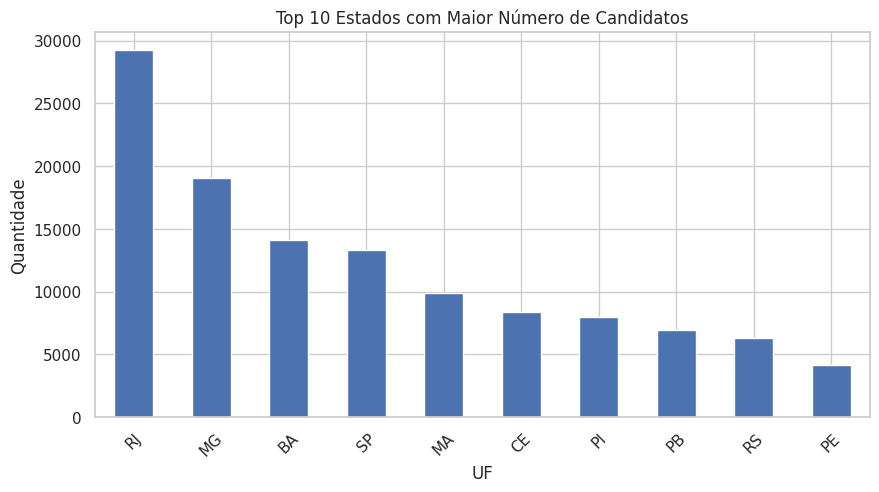

In [ ]:
plt.figure(figsize=(10,5))

sisu['UF_CANDIDATO'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Estados com Maior Número de Candidatos')
plt.xlabel('UF')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

plt.show()

Observa-se que os candidatos estão distribuídos por diversos estados brasileiros, com predominância do **Rio de Janeiro e Minas Gerais**. Essa concentração pode estar associada à localização das instituições participantes e à densidade populacional das regiões.

**Gráfico 3 – Distribuição dos Candidatos por Sexo**

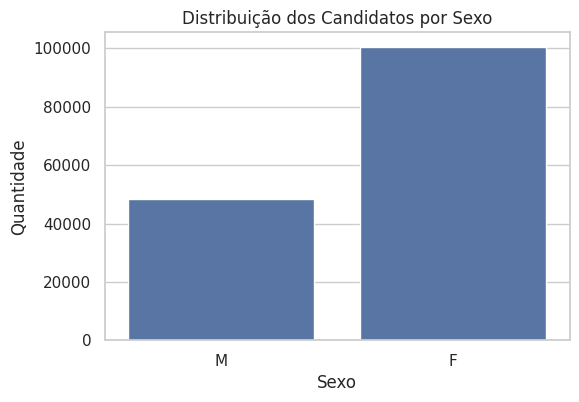

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=sisu,x='SEXO')

plt.title('Distribuição dos Candidatos por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')

plt.show()

A distribuição dos candidatos por sexo revela uma **predominância de candidatas do sexo feminino** na Lista de Espera do SISU 2023/2. Essa diferença pode estar relacionada ao perfil dos cursos ofertados, à distribuição dos inscritos no ENEM ou às características do processo seletivo.

**Gráfico 4 – Heatmap de Correlação das Variáveis Numéricas**

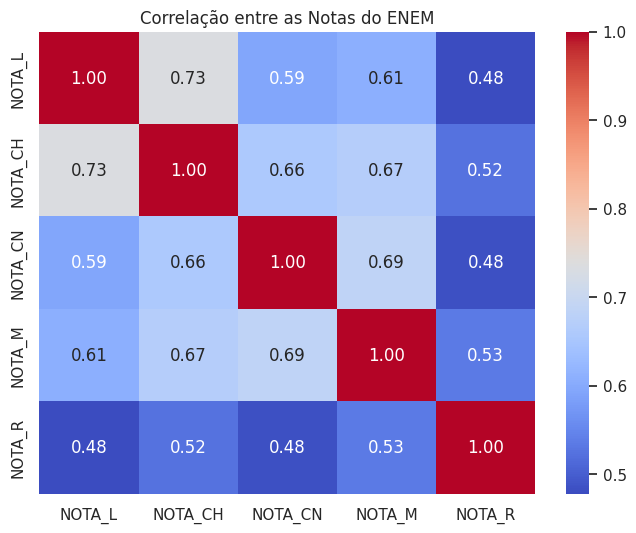

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

colunas_notas = [
    'NOTA_L',
    'NOTA_CH',
    'NOTA_CN',
    'NOTA_M',
    'NOTA_R'
]

# CONVERTER COLUNAS PARA FLOAT.
for coluna in colunas_notas:

    if sisu[coluna].dtype == 'object':

        sisu[coluna] = (
            sisu[coluna]
            .astype(str)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )

# CALCULAR CORRELAÇÃO
corr = sisu[colunas_notas].corr()

# PLOTAR HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlação entre as Notas do ENEM')

plt.show()

Observa-se correlação positiva moderada a forte entre todas as áreas do conhecimento. **As maiores correlações ocorreram entre Linguagens e Ciências Humanas (0,73) e entre Ciências da Natureza e Matemática (0,69)**. Isso indica que candidatos com bom desempenho em uma área tendem a apresentar desempenho acima da média em outras áreas. Apesar disso, nenhuma correlação foi suficientemente alta para caracterizar multicolinearidade severa, sugerindo que as variáveis podem ser mantidas na modelagem.

**Gráfico 5 - Distribuição da Nota do Candidato**

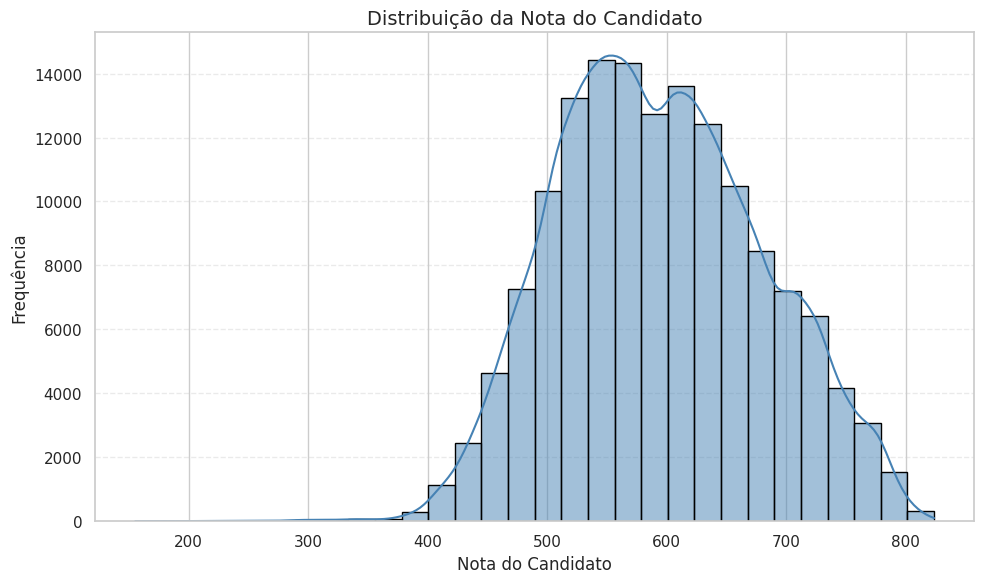

In [ ]:
# GRÁFICO 5 - DISTRIBUIÇÃO DA NOTA DO CANDIDATO

import matplotlib.pyplot as plt
import seaborn as sns

# Conversão temporária para tipo numérico (apenas para visualização)
nota_candidato = (
    sisu['NOTA_CANDIDATO']
        .astype(str)
        .str.replace(',', '.', regex=False)
        .astype(float)
)

# Configuração do gráfico
plt.figure(figsize=(10,6))

sns.histplot(
    nota_candidato,
    bins=30,
    kde=True,
    color='steelblue',
    edgecolor='black'
)

plt.title('Distribuição da Nota do Candidato', fontsize=14)
plt.xlabel('Nota do Candidato', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

A variável **NOTA_CANDIDATO** apresenta distribuição aproximadamente normal, **com concentração de candidatos entre 500 e 650 pontos**. Observa-se redução gradual da frequência nas extremidades da distribuição, indicando que notas muito baixas ou muito elevadas são menos comuns. Como essa variável representa o desempenho do candidato no processo seletivo, espera-se que ela possua relevância para prever a efetivação da matrícula.

**Gráfico 6 – Top 15 Cursos com Maior Número de Candidatos**

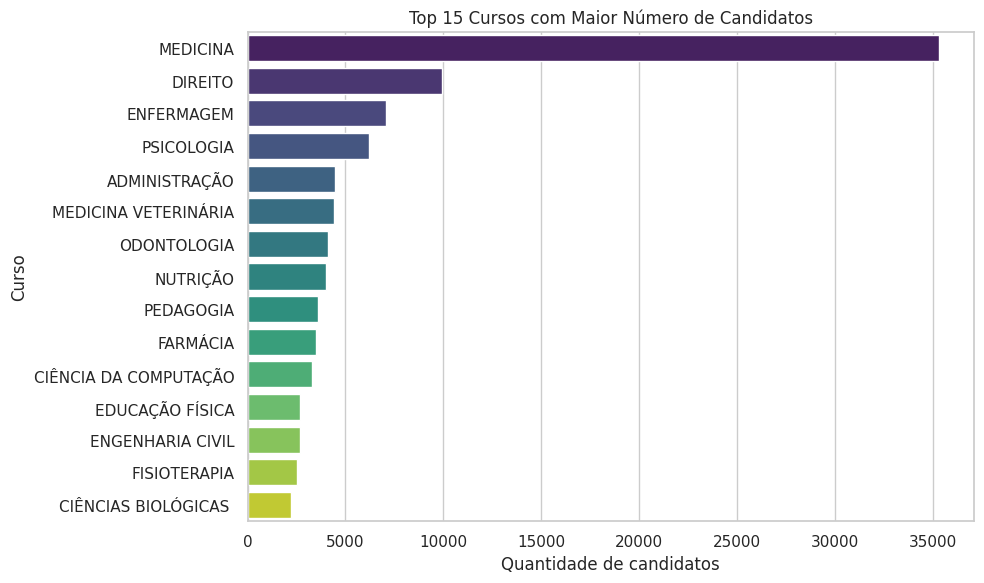

In [ ]:
top_cursos = (
    sisu['NOME_CURSO']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cursos.values,
    y=top_cursos.index,
    hue=top_cursos.index,
    palette='viridis',
    legend=False
)

plt.title('Top 15 Cursos com Maior Número de Candidatos')
plt.xlabel('Quantidade de candidatos')
plt.ylabel('Curso')

plt.tight_layout()
plt.show()

A distribuição dos candidatos por curso evidencia uma concentração significativa em algumas graduações, especialmente Medicina, que apresenta um número de candidatos muito superior aos demais cursos. **Esse comportamento pode estar relacionado à elevada concorrência e ao grande interesse dos candidatos por determinadas áreas de formação.**

**4. IDENTIFICAÇÃO E ANÁLISE DE OUTLIERS**

Nesta etapa são analisadas possíveis observações extremas (outliers) presentes nas variáveis numéricas do conjunto de dados. O objetivo é verificar se esses valores representam erros de registro ou características legítimas dos candidatos, definindo a necessidade (ou não) de tratamento antes da etapa de modelagem.

**4.1 Estatísticas Descritivas**

In [ ]:
sisu[['NOTA_CANDIDATO',
      'NOTA_L',
      'NOTA_CH',
      'NOTA_CN',
      'NOTA_M',
      'NOTA_R',
      'CLASSIFICACAO']].describe().T

,count,mean,std,min,25%,50%,75%,max
NOTA_CANDIDATO,148773.0,593.983839,85.820120,155.43,530.22,588.88,654.35,823.57
NOTA_L,148773.0,545.462792,69.912998,0.00,502.40,551.30,594.70,776.90
NOTA_CH,148773.0,560.204048,77.237059,0.00,510.40,561.70,613.80,829.10
NOTA_CN,148773.0,520.160758,81.913167,0.00,459.20,512.50,575.10,853.40
NOTA_M,148773.0,580.290811,125.917474,0.00,483.60,576.00,664.20,985.70
NOTA_R,148773.0,737.312953,152.866942,40.00,620.00,760.00,880.00,1000.00
CLASSIFICACAO,148773.0,73.908861,127.401748,1.00,9.00,26.00,78.00,1028.00


As estatísticas descritivas evidenciam diferenças importantes entre as variáveis analisadas. A **NOTA_CANDIDATO** apresenta média de aproximadamente 593,98 pontos, com mediana de 588,88, indicando distribuição relativamente concentrada em torno do centro da amostra. Entre as áreas do ENEM, observa-se maior dispersão nas notas de Matemática (desvio padrão = 125,92) e Redação (desvio padrão = 152,87), enquanto as demais disciplinas apresentam variabilidade menor. A variável CLASSIFICACAO apresenta elevada dispersão (desvio padrão = 127,40), sugerindo uma distribuição assimétrica com candidatos classificados em posições bastante distintas na lista de espera.

**4.2 Boxplot da Nota do Candidato**

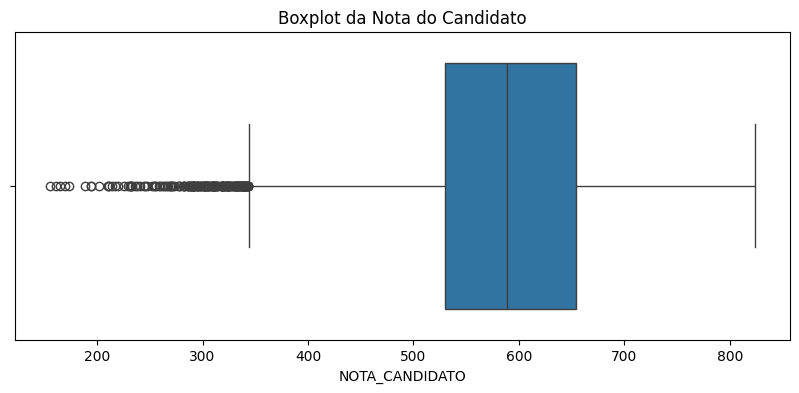

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=sisu['NOTA_CANDIDATO'])

plt.title('Boxplot da Nota do Candidato')

plt.show()

O boxplot da variável **NOTA_CANDIDATO** evidencia a presença de valores extremos inferiores, correspondentes a candidatos com desempenho significativamente inferior ao da maior parte da amostra. A maior concentração das notas encontra-se aproximadamente entre 530 e 650 pontos, com mediana próxima de 590 pontos. Não foram observados outliers superiores expressivos. Como essas observações representam desempenhos reais obtidos pelos candidatos no processo seletivo, não há indícios de erro de coleta ou registro. Portanto, esses valores serão mantidos na base de dados para preservar a variabilidade natural das notas.

**4.3 Boxplot das Notas do ENEM**

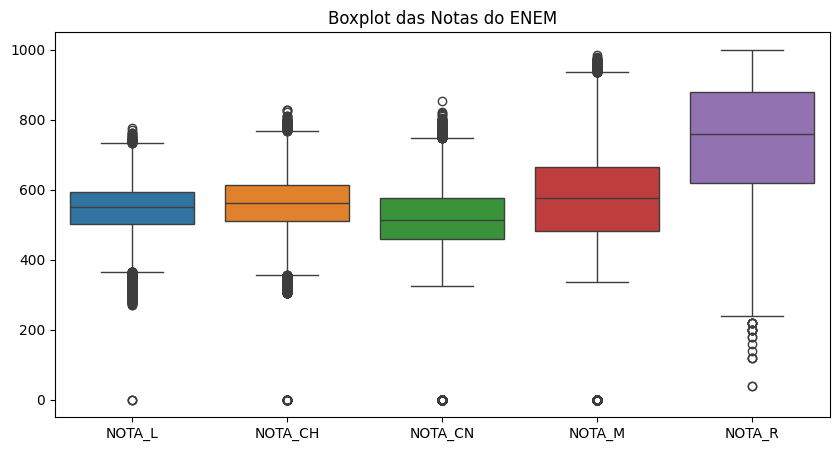

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=sisu[['NOTA_L','NOTA_CH','NOTA_CN','NOTA_M','NOTA_R']])

plt.title('Boxplot das Notas do ENEM')

plt.show()

Os boxplots das notas do ENEM revelam a presença de valores extremos em todas as áreas do conhecimento. Observam-se candidatos com desempenhos significativamente inferiores e superiores em relação ao restante da amostra, sendo a maior dispersão identificada na prova de Matemática, enquanto Redação apresenta a maior mediana entre as disciplinas avaliadas. Esses valores extremos são compatíveis com a variabilidade esperada do desempenho dos candidatos e não caracterizam inconsistências na base de dados. Dessa forma, optou-se por manter essas observações para preservar a representatividade dos dados utilizados na modelagem.

**4.4 Boxplot da Classificação**

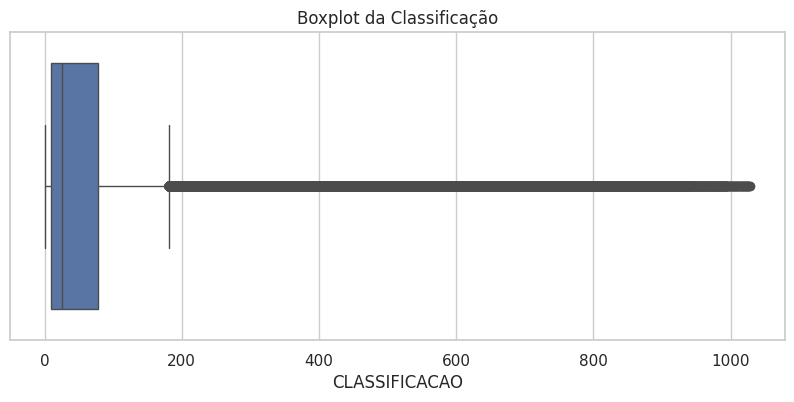

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=sisu['CLASSIFICACAO'])

plt.title('Boxplot da Classificação')

plt.show()

A variável **CLASSIFICACAO** apresenta distribuição fortemente assimétrica à direita, indicando concentração dos candidatos nas primeiras posições da lista de espera e uma cauda longa composta por candidatos classificados em posições mais elevadas. Os valores identificados como outliers representam candidatos efetivamente classificados em posições distantes da lista e fazem parte da dinâmica natural do processo seletivo. Dessa forma, esses registros não serão removidos, pois correspondem a observações legítimas e podem contribuir para a capacidade preditiva dos modelos.

**4.5 Verificação das Notas Iguais a Zero**

In [ ]:
(sisu[['NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M']] == 0).sum()

,0
NOTA_L,3
NOTA_CH,29
NOTA_CN,263
NOTA_M,263


In [ ]:
sisu.loc[
    (sisu['NOTA_L'] == 0) |
    (sisu['NOTA_CH'] == 0) |
    (sisu['NOTA_CN'] == 0) |
    (sisu['NOTA_M'] == 0),
    ['INSCRITO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN',
     'NOTA_M', 'NOTA_R', 'NOTA_CANDIDATO']
]

,INSCRITO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO
2374,MATHEUS MENDES DA SILVA MOTTA,545.2,602.5,0.0,0.0,340,297.54
2392,BRUNO DOS SANTOS QUERINO,423.8,354.7,0.0,0.0,680,291.70
2400,CACIANE REIS DA SILVA,349.7,407.4,0.0,0.0,400,231.42
2498,JEAN LUCAS ANDRADE FERREIRA,309.2,0.0,494.1,589.6,720,422.58
2592,LUCIANA CRISTINA MOURA DA SILVA SOUZA,401.0,472.5,0.0,0.0,640,302.70
...,...,...,...,...,...,...,...
128384,WALDEIR BARBOSA DA SILVA,471.7,504.9,0.0,0.0,640,298.08
128442,PEDRO CAMARGO CASANOVA,663.7,655.4,0.0,0.0,720,407.82
128744,ANA BEATRIZ ARAUJO TAVARES,471.5,448.5,0.0,0.0,500,238.00
129372,EDY MARLON SANTOS DA SILVA,555.0,611.1,0.0,0.0,640,354.35


Durante a análise das estatísticas descritivas, foram identificados poucos registros com nota igual a 0 nas provas de Linguagens, Ciências Humanas, Ciências da Natureza e Matemática. Como essa situação poderia indicar tanto desempenhos reais quanto possíveis inconsistências, foi realizada uma inspeção individual desses candidatos.

**4.6 Conclusão da Análise de Outliers**

A análise exploratória identificou valores extremos nas variáveis **NOTA_CANDIDATO**, **NOTAS DO ENEM** e **CLASSIFICACAO**. Entretanto, esses valores refletem diferenças reais no desempenho e na posição dos candidatos durante o processo seletivo, não havendo evidências de erros de registro ou inconsistências na base de dados.

Dessa forma, nenhum outlier será removido, uma vez que essas observações podem conter informações relevantes para o treinamento dos modelos de Machine Learning e representam adequadamente a variabilidade dos dados.

**ETAPA 2 - PRÉ PROCESSAMENTO**

Nesta etapa, o conjunto de dados é preparado para a construção dos modelos de Machine Learning. São realizadas a remoção de atributos irrelevantes para o problema de negócio, o tratamento dos valores ausentes, a criação de novas variáveis (feature engineering) e a adequação da variável-alvo ao Problema B.

**2.1 Criação da Base de Trabalho**

Para preservar a integridade da base original utilizada na Análise Exploratória de Dados (EDA), foi criada uma cópia do conjunto de dados. Todas as transformações realizadas nesta etapa serão aplicadas apenas sobre essa nova base.

In [ ]:
# CÓPIA DA BASE

sisu_limpo = sisu.copy()

print(sisu_limpo.shape)

(148773, 56)


**2.2 Remoção de Variáveis de Identificação**

Nesta etapa são removidas variáveis utilizadas apenas para identificação dos candidatos. Essas informações não possuem capacidade preditiva para o problema estudado e podem introduzir ruído durante o treinamento dos modelos.

In [ ]:
# REMOÇÃO DE ATRIBUTOS DE IDENTIFICAÇÃO

colunas_identificacao = [
    'CPF',
    'INSCRICAO_ENEM',
    'INSCRITO'
]

sisu_limpo.drop(columns=colunas_identificacao, inplace=True)

print(sisu_limpo.shape)

(148773, 53)


Foram removidos os atributos **CPF**, **INSCRICAO_ENEM** e **INSCRITO**, pois representam apenas informações de identificação dos candidatos e não possuem relação direta com a previsão da efetivação da matrícula. A permanência dessas variáveis poderia introduzir ruído no treinamento dos modelos sem contribuir para seu desempenho.

**2.3 Tratamento dos Valores Ausentes**

Nesta etapa são tratados os atributos que apresentaram valores ausentes durante a análise exploratória. Para cada variável foi adotada uma estratégia específica, considerando o significado dos dados e sua importância para o problema de negócio.

In [ ]:
# VERIFICAÇÃO INICIAL DOS VALORES AUSENTES
sisu_limpo.isnull().sum().sort_values(ascending=False)


# TP_COTA

sisu_limpo['TP_COTA'] = (
    sisu_limpo['TP_COTA']
        .fillna('AMPLA_CONCORRENCIA')
)

# PERCENTUAL_BONUS

sisu_limpo['PERCENTUAL_BONUS'] = (
    sisu_limpo['PERCENTUAL_BONUS']
        .fillna(0.0)
)


# NOTA_CORTE

sisu_limpo['NOTA_CORTE'] = (
    sisu_limpo['NOTA_CORTE']
        .astype(str)
        .str.replace(',', '.', regex=False)
)

sisu_limpo['NOTA_CORTE'] = pd.to_numeric(
    sisu_limpo['NOTA_CORTE'],
    errors='coerce'
)

mediana_corte = sisu_limpo['NOTA_CORTE'].median()

sisu_limpo['NOTA_CORTE'] = (
    sisu_limpo['NOTA_CORTE']
        .fillna(mediana_corte)
)

# VERIFICAÇÃO FINAL

sisu_limpo.isnull().sum().sort_values(ascending=False)

,0
ANO,0
EDICAO,0
ETAPA,0
DS_ETAPA,0
CODIGO_IES,0
NOME_IES,0
SIGLA_IES,0
UF_IES,0
CODIGO_CAMPUS,0
NOME_CAMPUS,0


Para o tratamento dos valores ausentes foram adotadas estratégias específicas para cada variável.

Na variável TP_COTA, os valores ausentes foram substituídos pela categoria **"AMPLA_CONCORRENCIA"**, considerando que a ausência dessa informação indica candidatos inscritos nessa modalidade.

Na variável **PERCENTUAL_BONUS**, os valores faltantes foram preenchidos com 0,0, pois a inexistência de registro indica que o candidato não recebeu bonificação.

Por fim, a variável **NOTA_CORTE** foi convertida para o tipo numérico e seus valores ausentes foram preenchidos utilizando a mediana da distribuição. Essa medida foi escolhida por ser robusta à presença de valores extremos e preservar melhor a distribuição original dos dados.

Após essas transformações, o conjunto de dados deixou de apresentar valores ausentes.

**2.4 Engenharia de Atributos (Feature Engineering)**

Nesta etapa são criadas novas variáveis derivadas das informações originais da base. Essas variáveis têm como objetivo representar características potencialmente relevantes para a previsão da efetivação da matrícula.

**2.4.1 Feature MESMA_UF**

In [ ]:
# BASE ESPECÍFICA DO PROBLEMA B
df_b = sisu_limpo.copy()

# CRIA A FEATURE MESMA_UF
df_b['MESMA_UF'] = (
    (df_b['UF_CANDIDATO'] == df_b['UF_CAMPUS'])
).astype(int)

df_b[
    ['UF_CANDIDATO', 'UF_CAMPUS', 'MESMA_UF']
].head()

,UF_CANDIDATO,UF_CAMPUS,MESMA_UF
0,RJ,RJ,1
1,RJ,RJ,1
2,RJ,RJ,1
3,SP,RJ,0
4,RJ,RJ,1


Foi criada a variável derivada **MESMA_UF**, conforme solicitado no enunciado do trabalho. Essa feature indica se o candidato reside na mesma Unidade Federativa do campus para o qual foi convocado.

Foi atribuído valor 1 quando as duas unidades federativas coincidem e 0 caso contrário.

Essa variável busca capturar um possível fator associado à decisão de efetivar a matrícula, considerando que candidatos convocados para instituições localizadas em seu próprio estado podem apresentar maior probabilidade de concluir o processo de matrícula.

**2.4.2 Feature MESMO_MUNICIPIO**

In [ ]:
# CRIA A FEATURE MESMO_MUNICIPIO

df_b['MESMO_MUNICIPIO'] = (
    (
        df_b['MUNICIPIO_CANDIDATO']
        ==
        df_b['MUNICIPIO_CAMPUS']
    )
).astype(int)

df_b[
    [
        'MUNICIPIO_CANDIDATO',
        'MUNICIPIO_CAMPUS',
        'MESMO_MUNICIPIO'
    ]
].head()

,MUNICIPIO_CANDIDATO,MUNICIPIO_CAMPUS,MESMO_MUNICIPIO
0,Rio de Janeiro,Rio de Janeiro,1
1,Rio de Janeiro,Rio de Janeiro,1
2,Resende,Rio de Janeiro,0
3,Rio Claro,Rio de Janeiro,0
4,Rio de Janeiro,Rio de Janeiro,1


Além da variável **MESMA_UF**, foi criada a feature **MESMO_MUNICIPIO**, que indica se o candidato reside no mesmo município do campus para o qual foi convocado.

Essa transformação preserva a informação geográfica relevante ao mesmo tempo em que reduz significativamente a elevada cardinalidade das variáveis **MUNICIPIO_CANDIDATO** e **MUNICIPIO_CAMPUS**, tornando essa informação mais adequada para utilização pelos algoritmos de Machine Learning.

**2.5 Adequação da Variável-Alvo (Problema B)**

Como o Problema B busca prever se um candidato convocado efetivará sua matrícula, foi necessário adequar a variável-alvo, removendo registros incompatíveis com o problema e transformando-a em uma variável binária.

In [ ]:
# REMOVE CANDIDATOS NÃO CONVOCADOS

df_b = df_b[
    df_b['MATRICULA'] != 'NÃO CONVOCADO'
].copy()

# TRANSFORMA A VARIÁVEL-ALVO EM BINÁRIA

df_b['MATRICULA'] = df_b['MATRICULA'].map({
    'EFETIVADA': 1,
    'NÃO COMPARECEU': 0,
    'DOCUMENTACAO REJEITADA': 0,
    'CANCELADA': 0,
    'PENDENTE': 0
})

print(df_b['MATRICULA'].value_counts())

MATRICULA
0    62101
1    16943
Name: count, dtype: int64


Para adequação ao Problema B, a variável MATRICULA foi transformada em uma variável binária.

Os candidatos com matrícula EFETIVADA receberam valor 1, representando os casos em que a matrícula foi concluída com sucesso.

As categorias NÃO COMPARECEU, DOCUMENTACAO REJEITADA, CANCELADA e PENDENTE receberam valor 0, indicando candidatos que não efetivaram a matrícula.

Além disso, os registros classificados como NÃO CONVOCADO foram removidos, pois o problema proposto considera exclusivamente candidatos que já foram convocados.

**2.6 Seleção de Variáveis e Codificação das Variáveis Categóricas**

Nesta etapa, as variáveis categóricas são transformadas em representações numéricas para que possam ser utilizadas pelos algoritmos de Machine Learning. Foram adotadas duas estratégias de codificação:

**One-Hot Encoding** para variáveis categóricas sem ordem natural.

**Ordinal Encoding** apenas para variáveis categóricas com ordem ou representação numérica natural.

Além disso, foram removidas variáveis de identificação, atributos redundantes e informações com potencial de data leakage, mantendo apenas as features consideradas relevantes para o Problema B.

In [ ]:
# ETAPA 2.6 - CODIFICAÇÃO DAS VARIÁVEIS CATEGÓRICAS

from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# CÓPIA DA BASE
df_b_modelo = df_b.copy()

# CRIA A FEATURE IDADE
# DT_NASCIMENTO contém apenas o ano de nascimento
df_b_modelo['IDADE'] = 2023 - df_b_modelo['DT_NASCIMENTO']

# Remove o ano de nascimento
df_b_modelo.drop(columns='DT_NASCIMENTO', inplace=True)


# CONVERSÃO DAS VARIÁVEIS NUMÉRICAS

colunas_numericas = [

    'NOTA_L',
    'NOTA_CH',
    'NOTA_CN',
    'NOTA_M',
    'NOTA_R',

    'NOTA_CANDIDATO',
    'NOTA_CORTE',

    'QT_VAGAS_CONCORRENCIA',

    'IDADE',

    'CODIGO_CURSO',
    'OPCAO'

]

for coluna in colunas_numericas:

    if coluna in df_b_modelo.columns:

        df_b_modelo[coluna] = pd.to_numeric(

            df_b_modelo[coluna]
                .astype(str)
                .str.replace(',', '.', regex=False),

            errors='coerce'

        )


# REMOÇÃO DAS FEATURES DESNECESSÁRIAS

colunas_remover = [


    # DATA LEAKAGE
    'APROVADO',
    'CLASSIFICACAO',


    # IDENTIFICAÇÃO
    'CPF',
    'INSCRICAO_ENEM',
    'INSCRITO',

    # IDENTIFICADORES
    'CODIGO_CAMPUS',
    'CODIGO_IES',

    # REDUNDANTES
    'NOME_IES',
    'SIGLA_IES',
    'NOME_CAMPUS',
    'NOME_CURSO',

    # GEOGRÁFICAS
    'UF_IES',
    'UF_CAMPUS',
    'MUNICIPIO_CANDIDATO',
    'MUNICIPIO_CAMPUS',

    # PESOS
    'PESO_L',
    'PESO_CH',
    'PESO_CN',
    'PESO_M',
    'PESO_R',

    # NOTAS MÍNIMAS
    'NOTA_MINIMA_L',
    'NOTA_MINIMA_CH',
    'NOTA_MINIMA_CN',
    'NOTA_MINIMA_M',
    'NOTA_MINIMA_R',

    'MEDIA_MINIMA',

    # NOTAS COM PESO
    'NOTA_L_COM_PESO',
    'NOTA_CH_COM_PESO',
    'NOTA_CN_COM_PESO',
    'NOTA_M_COM_PESO',
    'NOTA_R_COM_PESO'

]

df_b_modelo.drop(
    columns=colunas_remover,
    inplace=True,
    errors='ignore'
)

# REMOÇÃO DE VARIÁVEIS CONSTANTES
colunas_constantes = [
    coluna
    for coluna in df_b_modelo.columns
    if df_b_modelo[coluna].nunique() == 1
]

print("Variáveis constantes removidas:")
print(colunas_constantes)

df_b_modelo.drop(
    columns=colunas_constantes,
    inplace=True
)

# VARIÁVEIS CATEGÓRICAS
colunas_categoricas = df_b_modelo.select_dtypes(
    include='object'
).columns.tolist()

if 'MATRICULA' in colunas_categoricas:
    colunas_categoricas.remove('MATRICULA')

# ORDINAL ENCODING
encoder = OrdinalEncoder(

    handle_unknown='use_encoded_value',
    unknown_value=-1

)

df_b_modelo[colunas_categoricas] = encoder.fit_transform(
    df_b_modelo[colunas_categoricas]
)

# SEPARAÇÃO ENTRE X E y
X = df_b_modelo.drop(columns='MATRICULA')

y = df_b_modelo['MATRICULA']

# VERIFICAÇÕES

print(f'Número de registros : {X.shape[0]}')
print(f'Número de features  : {X.shape[1]}')
print(f'Valores ausentes    : {X.isnull().sum().sum()}')

print("\nFeatures utilizadas:")
print(list(X.columns))

display(X.head())

Variáveis constantes removidas:
['ANO', 'EDICAO', 'ETAPA', 'DS_ETAPA']
Número de registros : 79044
Número de features  : 22
Valores ausentes    : 0

Features utilizadas:
['CODIGO_CURSO', 'GRAU', 'TURNO', 'DS_PERIODICIDADE', 'TP_COTA', 'TIPO_MOD_CONCORRENCIA', 'MOD_CONCORRENCIA', 'QT_VAGAS_CONCORRENCIA', 'PERCENTUAL_BONUS', 'SEXO', 'UF_CANDIDATO', 'OPCAO', 'NOTA_L', 'NOTA_CH', 'NOTA_CN', 'NOTA_M', 'NOTA_R', 'NOTA_CANDIDATO', 'NOTA_CORTE', 'MESMA_UF', 'MESMO_MUNICIPIO', 'IDADE']


,CODIGO_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,UF_CANDIDATO,OPCAO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO,NOTA_CORTE,MESMA_UF,MESMO_MUNICIPIO,IDADE
6,1441998,0.0,3.0,1.0,0.0,0.0,1.0,15,0.0,1.0,18.0,2,622.5,623.6,611.9,782.1,700,699.85,660.69,1,1,18
7,1441998,0.0,3.0,1.0,0.0,0.0,1.0,15,0.0,1.0,18.0,1,605.9,664.8,589.9,767.7,760,709.21,660.69,1,1,18
26,1441998,0.0,3.0,1.0,0.0,0.0,1.0,15,0.0,0.0,18.0,1,608.7,621.7,585.1,632.7,920,699.22,660.69,1,1,20
31,1441998,0.0,3.0,1.0,0.0,0.0,1.0,15,0.0,1.0,15.0,2,530.7,652.2,619.7,706.2,820,700.65,660.69,0,0,21
33,1441998,0.0,3.0,1.0,0.0,0.0,1.0,15,0.0,1.0,18.0,1,615.6,638.1,604.5,724.4,760,694.57,660.69,1,0,25


As variáveis categóricas foram convertidas para representações numéricas utilizando Ordinal Encoding, estratégia escolhida para reduzir a dimensionalidade da base de dados e torná-la compatível com os algoritmos de Machine Learning utilizados neste trabalho. Como os modelos avaliados são baseados principalmente em árvores de decisão, essa abordagem preserva a distinção entre as categorias sem gerar um grande número de atributos adicionais, como ocorreria com a aplicação de One-Hot Encoding.

Além da codificação, foi realizada uma etapa de seleção de atributos. Foram removidas variáveis de identificação (CPF, INSCRICAO_ENEM e INSCRITO), atributos com potencial de vazamento de informação (data leakage), como APROVADO e CLASSIFICACAO, bem como variáveis redundantes e identificadores que não agregam capacidade preditiva ao modelo, como nomes de instituições, campus e cursos.

As variáveis geográficas originais (UF_CAMPUS, MUNICIPIO_CANDIDATO e MUNICIPIO_CAMPUS) também foram removidas, uma vez que suas informações passaram a ser representadas pelas features derivadas MESMA_UF e MESMO_MUNICIPIO, criadas na etapa de engenharia de atributos.

Adicionalmente, o atributo DT_NASCIMENTO foi substituído pela variável IDADE, proporcionando uma representação mais interpretável da característica do candidato. Por fim, variáveis constantes foram identificadas e removidas automaticamente, pois não apresentam variabilidade e, consequentemente, não contribuem para o processo de aprendizado dos modelos.


**ETAPA 3 – Separação Treino/Teste**

In [ ]:
from sklearn.model_selection import train_test_split


# ETAPA 3 - SEPARAÇÃO TREINO / TESTE

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print(f"Treino : {X_train.shape}")
print(f"Teste  : {X_test.shape}")

print("\nDistribuição das classes (Treino)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribuição das classes (Teste)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Treino : (63235, 22)
Teste  : (15809, 22)

Distribuição das classes (Treino)
MATRICULA
0    78.57
1    21.43
Name: proportion, dtype: float64

Distribuição das classes (Teste)
MATRICULA
0    78.56
1    21.44
Name: proportion, dtype: float64


O conjunto de dados foi dividido em 80% para treinamento e 20% para teste, utilizando amostragem estratificada (stratify=y). Essa estratégia preserva a proporção das classes da variável-alvo em ambos os conjuntos, reduzindo o risco de desequilíbrios que possam comprometer a avaliação dos modelos.

Além disso, foi definido random_state=42, garantindo a reprodutibilidade dos experimentos.

**ETAPA 4 – Padronização das Variáveis Numéricas**

In [ ]:
from sklearn.preprocessing import StandardScaler


# ETAPA 4 - PADRONIZAÇÃO

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(

    scaler.fit_transform(X_train),

    columns=X_train.columns,

    index=X_train.index

)

X_test_scaled = pd.DataFrame(

    scaler.transform(X_test),

    columns=X_test.columns,

    index=X_test.index

)

print(f"Treino normalizado : {X_train_scaled.shape}")
print(f"Teste normalizado  : {X_test_scaled.shape}")

import numpy as np

print("========== VERIFICAÇÕES ==========")

print(f"Treino - NaN        : {X_train_scaled.isnull().sum().sum()}")
print(f"Teste  - NaN        : {X_test_scaled.isnull().sum().sum()}")

print(f"Treino - Infinitos  : {np.isinf(X_train_scaled.values).sum()}")
print(f"Teste  - Infinitos  : {np.isinf(X_test_scaled.values).sum()}")

print(f"Número de features  : {X_train_scaled.shape[1]}")

Treino normalizado : (63235, 22)
Teste normalizado  : (15809, 22)
========== VERIFICAÇÕES ==========
Treino - NaN        : 0
Teste  - NaN        : 0
Treino - Infinitos  : 0
Teste  - Infinitos  : 0
Número de features  : 22


A padronização das variáveis foi realizada utilizando o StandardScaler, ajustado exclusivamente sobre o conjunto de treinamento. Em seguida, a mesma transformação foi aplicada ao conjunto de teste.

Essa abordagem evita vazamento de informação (data leakage), uma vez que estatísticas do conjunto de teste não são utilizadas durante o treinamento dos modelos. A padronização é especialmente importante para algoritmos sensíveis à escala das variáveis, como KNN e SVM.

**ETAPA 5 Balanceamento das Classes (SMOTE)**

**5.1 Objetivo**

Como a variável-alvo apresenta desbalanceamento entre as classes, foi utilizada a técnica SMOTE (Synthetic Minority Over-sampling Technique) para balancear apenas o conjunto de treinamento. Essa abordagem reduz o viés dos modelos em favor da classe majoritária e melhora a capacidade de identificar candidatos que efetivarão a matrícula.

**5.2 Distribuição das Classes Antes do Balanceamento**

In [ ]:
print("Distribuição da variável-alvo antes do SMOTE (Treino):")

print(y_train.value_counts())

print("\nPercentual:")

print((y_train.value_counts(normalize=True)*100).round(2))

Distribuição da variável-alvo antes do SMOTE (Treino):
MATRICULA
0    49681
1    13554
Name: count, dtype: int64

Percentual:
MATRICULA
0    78.57
1    21.43
Name: proportion, dtype: float64


**Distribuição das Classes Antes do SMOTE**

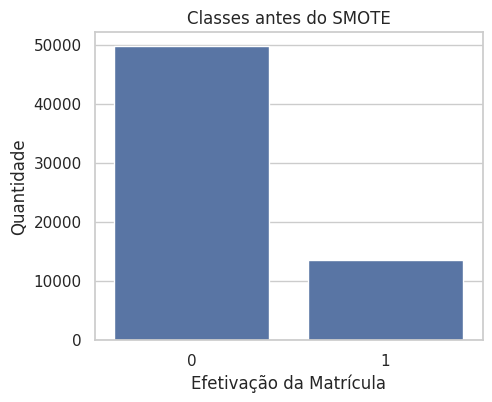

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Classes antes do SMOTE")

plt.xlabel("Efetivação da Matrícula")

plt.ylabel("Quantidade")

plt.show()

**5.3 Aplicação do SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanceado, y_train_balanceado = smote.fit_resample(
    X_train_scaled,
    y_train)

**5.4 Distribuição das Classes Após o Balanceamento**

**Distribuição das Classes Após o SMOTE**

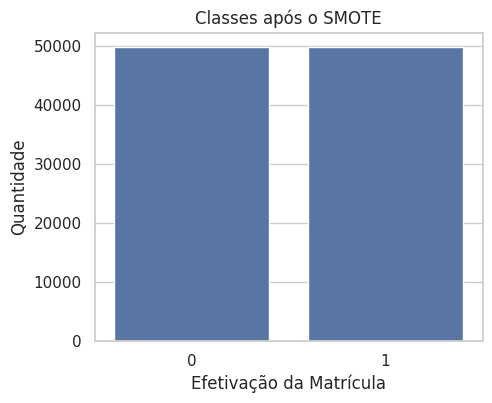

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x=y_train_balanceado)

plt.title("Classes após o SMOTE")

plt.xlabel("Efetivação da Matrícula")

plt.ylabel("Quantidade")

plt.show()

**5.5 Interpretação**

Antes da aplicação do SMOTE, observou-se que o conjunto de treinamento apresentava um desbalanceamento significativo entre as classes da variável-alvo. Aproximadamente 78,6% dos registros correspondiam a candidatos que não efetivaram a matrícula, enquanto apenas 21,4% representavam candidatos que efetivaram.

Para reduzir esse desequilíbrio foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique) exclusivamente sobre o conjunto de treinamento. Essa técnica gera novas amostras sintéticas da classe minoritária a partir da interpolação entre observações existentes, promovendo um balanceamento sem simplesmente replicar registros.

Após a aplicação do SMOTE, ambas as classes passaram a apresentar a mesma quantidade de observações (49.681 registros), resultando em uma distribuição equilibrada (50% / 50%). O conjunto de teste permaneceu inalterado para garantir uma avaliação imparcial do desempenho dos modelos

In [ ]:
print("Distribuição da variável-alvo após o SMOTE:")

print(y_train_balanceado.value_counts())

print("\nPercentual:")

print((y_train_balanceado.value_counts(normalize=True)*100).round(2))

Distribuição da variável-alvo após o SMOTE:
MATRICULA
1    49681
0    49681
Name: count, dtype: int64

Percentual:
MATRICULA
1    50.0
0    50.0
Name: proportion, dtype: float64


In [ ]:
# Converte novamente para DataFrame
X_train_balanceado = pd.DataFrame(
    X_train_balanceado,
    columns=X_train_scaled.columns
)

**5.6 Verificações de Integridade**

In [ ]:
import numpy as np

print("========== VERIFICAÇÕES FINAIS ==========\n")

print("CONJUNTO DE TREINAMENTO (SMOTE)")
print(f"Valores ausentes : {X_train_balanceado.isnull().sum().sum()}")
print(f"Valores infinitos: {np.isinf(X_train_balanceado.values).sum()}")
print(f"Registros duplicados: {X_train_balanceado.duplicated().sum()}")
print(f"Shape: {X_train_balanceado.shape}")

print("\n----------------------------------------\n")

print("CONJUNTO DE TESTE")
print(f"Valores ausentes : {X_test_scaled.isnull().sum().sum()}")
print(f"Valores infinitos: {np.isinf(X_test_scaled.values).sum()}")
print(f"Registros duplicados: {X_test_scaled.duplicated().sum()}")
print(f"Shape: {X_test_scaled.shape}")

========== VERIFICAÇÕES FINAIS ==========

CONJUNTO DE TREINAMENTO (SMOTE)
Valores ausentes : 0
Valores infinitos: 0
Registros duplicados: 0
Shape: (99362, 22)

----------------------------------------

CONJUNTO DE TESTE
Valores ausentes : 0
Valores infinitos: 0
Registros duplicados: 0
Shape: (15809, 22)


Após a aplicação da padronização das variáveis e do balanceamento das classes por meio da técnica SMOTE, foi realizada uma verificação da integridade dos conjuntos de treinamento e teste. Não foram identificados valores ausentes (NaN), valores infinitos ou registros duplicados em nenhum dos conjuntos de dados.

O conjunto de treinamento passou a conter 99.362 registros distribuídos de forma equilibrada entre as duas classes da variável-alvo, enquanto o conjunto de teste permaneceu inalterado, com 15.809 registros, preservando sua distribuição original para garantir uma avaliação imparcial dos modelos. Dessa forma, ambos os conjuntos encontram-se consistentes e adequados para a etapa de treinamento e validação dos algoritmos de Machine Learning.

**5.7 Base Final para Modelagem**

In [ ]:
print("Treinamento :", X_train_balanceado.shape)
print("Teste       :", X_test_scaled.shape)

print("\nClasses (Treino)")
print(y_train_balanceado.value_counts())

print("\nClasses (Teste)")
print(y_test.value_counts())

Treinamento : (99362, 22)
Teste       : (15809, 22)

Classes (Treino)
MATRICULA
1    49681
0    49681
Name: count, dtype: int64

Classes (Teste)
MATRICULA
0    12420
1     3389
Name: count, dtype: int64


Ao final do pré-processamento, a base de dados encontra-se preparada para a etapa de modelagem. O conjunto de treinamento foi balanceado utilizando a técnica SMOTE, enquanto o conjunto de teste foi mantido inalterado, permitindo uma avaliação mais realista da capacidade de generalização dos modelos.

**5.8 Salvando a Base Processada**

In [ ]:
# SALVAR AS BASES PROCESSADAS

# Base de treinamento (balanceada com SMOTE)
df_treino = X_train_balanceado.copy()
df_treino['MATRICULA'] = y_train_balanceado.values

# Base de teste (mantida original)
df_teste = X_test_scaled.copy()
df_teste['MATRICULA'] = y_test.values

print("Base de treinamento:", df_treino.shape)
print("Base de teste:", df_teste.shape)

display(df_treino.head())
display(df_teste.head())

Base de treinamento: (99362, 23)
Base de teste: (15809, 23)


,CODIGO_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,UF_CANDIDATO,OPCAO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO,NOTA_CORTE,MESMA_UF,MESMO_MUNICIPIO,IDADE,MATRICULA
0,0.256133,-0.451890,-0.673736,0.128932,-0.669029,-0.061029,2.090035,0.743401,2.939621,1.400306,-0.016474,-0.688583,1.233243,1.569866,2.097158,2.208128,1.552405,2.055747,1.402944,-1.644456,-0.658020,0.064502,1
1,-0.242948,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,0.548206,-0.206526,-0.714130,0.832991,-0.688583,0.163910,0.094882,0.162337,0.146458,0.496112,0.233991,0.855121,-1.644456,-0.658020,-0.263192,0
2,-0.201938,-0.451890,1.329400,0.128932,-0.669029,-1.015803,-0.961108,2.207358,-0.206526,-0.714130,-1.290671,-0.688583,-0.032498,0.751608,0.382288,0.099788,1.420368,0.708437,0.736849,0.608104,-0.658020,0.064502,0
3,-0.243816,1.100101,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,0.450609,-0.206526,-0.714130,-0.865939,-0.688583,0.275935,-0.593620,0.605967,0.324132,-1.088327,-0.295296,-0.248409,0.608104,-0.658020,-0.427039,0
4,-0.202583,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,1.133789,-0.206526,-0.714130,0.691413,-0.688583,0.032971,-2.006374,-1.130028,-1.396110,0.364075,-0.928455,-0.073229,0.608104,1.519711,-0.590887,1


,CODIGO_CURSO,GRAU,TURNO,DS_PERIODICIDADE,TP_COTA,TIPO_MOD_CONCORRENCIA,MOD_CONCORRENCIA,QT_VAGAS_CONCORRENCIA,PERCENTUAL_BONUS,SEXO,UF_CANDIDATO,OPCAO,NOTA_L,NOTA_CH,NOTA_CN,NOTA_M,NOTA_R,NOTA_CANDIDATO,NOTA_CORTE,MESMA_UF,MESMO_MUNICIPIO,IDADE,MATRICULA
12493,0.330668,-0.451890,-0.673736,0.128932,1.763425,0.893744,0.610693,-0.622960,-0.206526,1.400306,-1.715403,-0.688583,-0.809402,-2.539964,-0.291233,-0.378375,-1.748510,-1.242130,-1.249665,0.608104,-0.658020,-0.427039,0
7442,0.284203,-0.451890,-0.673736,0.128932,-0.669029,1.848517,-0.498814,-1.110945,-0.206526,-0.714130,1.824033,1.452257,0.485437,0.933002,-0.447808,0.485430,0.496112,0.286654,1.711023,0.608104,-0.658020,-0.427039,0
39443,-0.201938,-0.451890,1.329400,0.128932,1.763425,0.893744,0.610693,0.157818,-0.206526,-0.714130,-1.290671,-0.688583,1.058658,0.743663,0.905448,-0.050866,-0.032035,0.454205,0.091552,0.608104,-0.658020,-0.263192,0
21195,0.203258,1.100101,0.327832,0.128932,-0.669029,-1.015803,-0.961108,0.157818,-0.206526,1.400306,0.266681,1.452257,-0.736658,-1.127210,0.520223,-0.868001,-1.616474,-1.109687,-1.066258,0.608104,1.519711,-0.427039,0
44439,-0.243626,-0.451890,-0.673736,0.128932,-0.669029,-1.015803,-0.961108,1.914567,-0.206526,1.400306,-1.290671,-0.688583,0.910261,1.364640,1.039655,0.912830,1.156295,1.161455,1.654229,0.608104,-0.658020,-0.427039,0


In [ ]:
# SALVAR AS BASES TRATADAS EM FORMATO PICKLE

df_treino.to_pickle('bas_treino.pkl')
df_teste.to_pickle('problema_b_teste.pkl')

print("Arquivos salvos com sucesso!")

Arquivos salvos com sucesso!


**5.9 Exportação dos Dados**

In [ ]:
from google.colab import files

files.download('base_treino.pkl')
files.download('base_teste.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>